# Model Implementation in Python (Appendix)

In the previous sections of this project, models were developed using AutoML platforms to identify the most suitable algorithms for each business question. While AutoML provides strong performance and model selection capabilities, it is important to ensure that these models are fully understood and reproducible.

This notebook replicates the selected models using standard Python libraries. The objective is to demonstrate that the same modeling logic, structure, and insights can be achieved without relying on AutoML tools.

Three models are implemented:

1. Regression Model – to predict traffic volume  
2. Classification Model – to identify high traffic conditions  
3. Time Series Model – to forecast future traffic demand  

Each section follows a structured approach:
- Problem definition  
- Model implementation  
- Evaluation and visualization  
- Business interpretation  

This ensures that the models are not treated as black-box outputs but as interpretable and actionable analytical tools.

## Regression Model: Predicting Traffic Volume

### Objective

The objective of this model is to predict total traffic volume across facilities.

### Why Regression?

Since the target variable (TOTAL) is continuous, a regression model is appropriate. This allows us to estimate actual traffic levels and understand how different factors influence traffic behavior.

### Model Selection

Based on AutoML results, a Gradient Boosting Machine (GBM) was selected due to its strong performance and ability to capture non-linear relationships.

### Variables

- Dependent Variable: TOTAL  
- Independent Variables: Facility, DayOfWeek, weather variables, passenger and bus volumes  

Variables that directly contribute to TOTAL (such as CASH, EZPASS, and vehicle-type counts) were excluded to avoid data leakage and ensure meaningful interpretation.

In [3]:
# =====================================
# REGRESSION MODEL (FINAL FIXED VERSION)
# =====================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Copy dataset
traffic_data = pd.read_csv("../data/integrated/final_master_sample.csv")
data = traffic_data.copy()

# -------------------------------
# Drop columns NOT used in AutoML
# -------------------------------
data = data.drop(columns=["DATE", "Month_Year"], errors="ignore")

# -------------------------------
# Target
# -------------------------------
y = data["TOTAL"]

# -------------------------------
# Features (same as AutoML)
# -------------------------------
X = data.drop(columns=[
    "TOTAL", "CASH", "EZPASS", "VIOLATION",
    "Autos", "Small_T", "Large_T", "Buses", "STATION"
])

# -------------------------------
# Convert categorical
# -------------------------------
X = pd.get_dummies(X, columns=["FAC", "DayOfWeek"], drop_first=True)

X = X.apply(pd.to_numeric, errors="coerce")

# Replace any NaNs created
X = X.fillna(0)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Model (AutoML GBM equivalent)
# -------------------------------
model_reg = GradientBoostingRegressor(
    n_estimators=121,
    max_depth=7,
    learning_rate=0.05,
    random_state=42
)

# Train
model_reg.fit(X_train, y_train)

# Predict
y_pred = model_reg.predict(X_test)

# Evaluate
import numpy as np

print("Regression Model Results")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

print("R2 Score:", r2_score(y_test, y_pred))


Regression Model Results
RMSE: 4623.704227095479
R2 Score: 0.9385924556912814


### Model Performance

The regression model achieves strong performance:

- RMSE ≈ 4623  
- R² ≈ 0.94  

This indicates that the model explains approximately 94% of the variation in traffic volume, which is a strong result for real-world data.

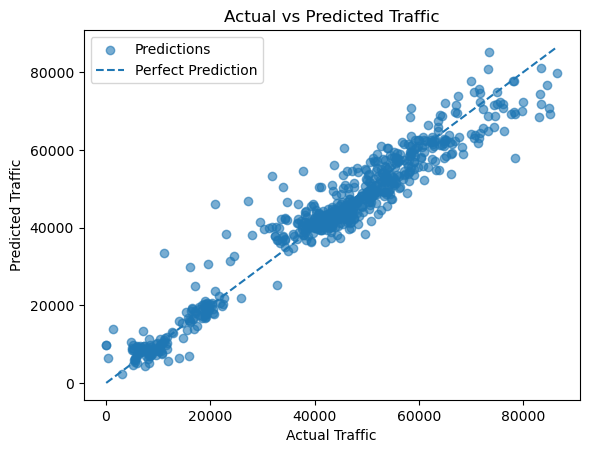

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred, alpha=0.6, label="Predictions")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")
plt.title("Actual vs Predicted Traffic")

plt.legend()

plt.show()

### Actual vs Predicted Analysis

The scatter plot compares actual traffic values with model predictions. The dashed diagonal line represents perfect predictions.

The close alignment of points along this line indicates that the model is accurately capturing traffic patterns across different conditions.

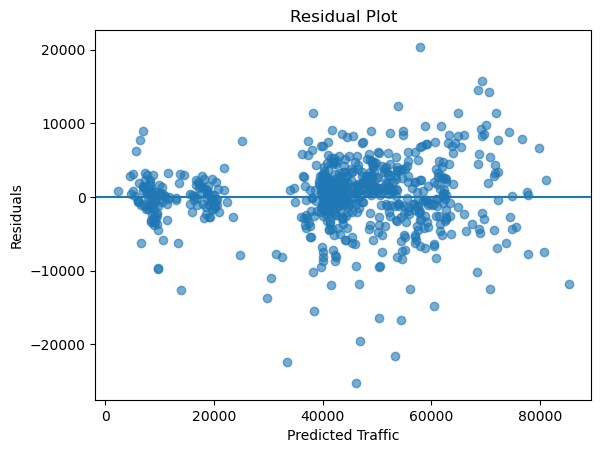

In [8]:
import matplotlib.pyplot as plt

#  DEFINE residuals FIRST
residuals = y_test - y_pred

plt.figure()

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0)

plt.xlabel("Predicted Traffic")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Residual Analysis

The residual plot shows that prediction errors are centered around zero, with no clear pattern.

This indicates that the model does not suffer from systematic bias and is capturing the underlying relationships effectively. A slight increase in variance at higher traffic levels is observed, which is expected in real-world traffic data.

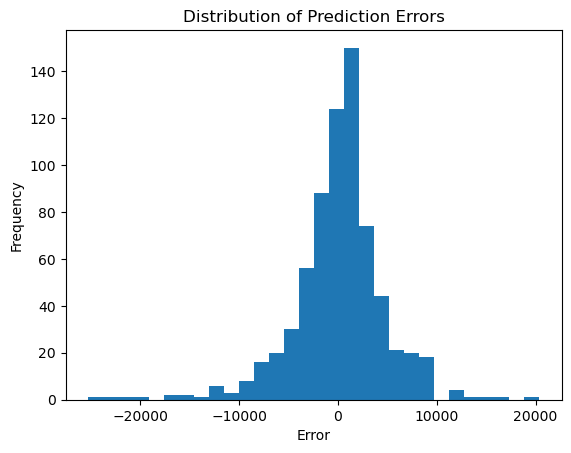

In [9]:
plt.figure()

plt.hist(residuals, bins=30)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

### Error Distribution

The distribution of prediction errors is approximately normal and centered near zero.

This confirms that the model produces balanced predictions without consistent overestimation or underestimation.

## Classification Model: Identifying High Traffic Conditions

### Objective

The objective of this model is to classify whether a given time period corresponds to high traffic conditions.

### Why Classification?

Instead of predicting exact traffic values, this model categorizes traffic into high and normal levels. This is useful for identifying congestion-prone periods.

### Target Definition

High traffic is defined as traffic levels above the 75th percentile.

### Model Selection

A Random Forest classifier was selected based on AutoML results, as it effectively handles non-linear relationships and interactions between variables.

In [10]:
# =====================================
# CLASSIFICATION MODEL (Q4) — FINAL
# =====================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Copy dataset
data = traffic_data.copy()

# -------------------------------
# Drop unwanted columns
# -------------------------------
data = data.drop(columns=["DATE", "Month_Year"], errors="ignore")

# -------------------------------
# Create target
# -------------------------------
threshold = data["TOTAL"].quantile(0.75)
data["High_Traffic"] = (data["TOTAL"] >= threshold).astype(int)

# -------------------------------
# Features
# -------------------------------
X = data.drop(columns=[
    "TOTAL", "CASH", "EZPASS", "VIOLATION",
    "Autos", "Small_T", "Large_T", "Buses",
    "STATION", "High_Traffic"
])

y = data["High_Traffic"]

# Encode categorical
X = pd.get_dummies(X, columns=["FAC", "DayOfWeek"], drop_first=True)

# Force numeric
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

# -------------------------------
# Split
# -------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Model
# -------------------------------
model_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

model_clf.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = model_clf.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------
print("\nClassification Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Classification Model Results
Accuracy: 0.9194244604316547
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       523
           1       0.84      0.84      0.84       172

    accuracy                           0.92       695
   macro avg       0.89      0.89      0.89       695
weighted avg       0.92      0.92      0.92       695



### Model Performance

The classification model achieves an accuracy of approximately 91.9%, indicating strong predictive capability.

The model performs well across both classes, with slightly higher precision and recall for normal traffic compared to high traffic conditions.

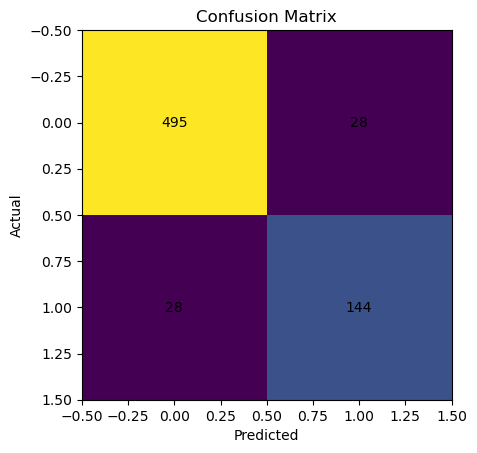

In [11]:
# -------------------------------
# 🔥 VISUAL 1: Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that:

- Most normal traffic cases are correctly classified  
- High traffic conditions are also identified with strong accuracy  

Misclassification is relatively low, indicating that the model is reliable for identifying congestion periods.

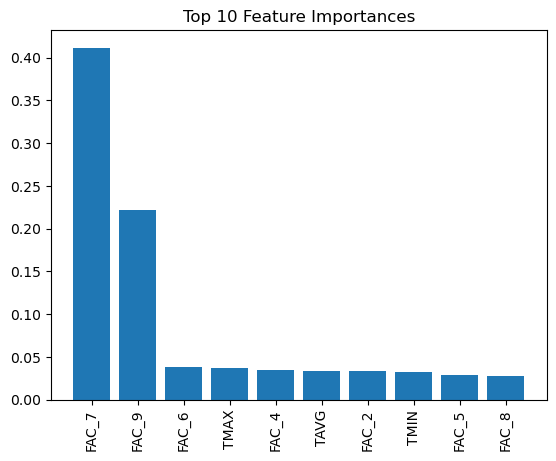

In [12]:
# -------------------------------
# 🔥 VISUAL 2: Feature Importance
# -------------------------------
importances = model_clf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure()
plt.title("Top 10 Feature Importances")
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), X.columns[indices], rotation=90)
plt.show()

### Feature Importance Analysis

The feature importance plot shows that facility-related variables (particularly FAC_7 and FAC_9) are the strongest predictors of high traffic conditions.

Weather variables such as temperature also contribute to classification, but to a lesser extent.

This confirms that traffic congestion is driven primarily by infrastructure characteristics, with environmental factors playing a supporting role.

## Time Series Model: Forecasting Traffic Demand

### Objective

The objective of this model is to forecast future traffic demand beyond 2025.

### Why Time Series?

Traffic data is sequential and influenced by historical patterns, making time-series modeling the appropriate approach.

### Modeling Approach

A SARIMA model was used to capture both trend and seasonality in the data.

### Facility Selection

Facility 7 was selected for forecasting because it represents one of the highest-traffic facilities. High-volume facilities are operationally critical and provide meaningful insights into future congestion patterns.

In [13]:
# =====================================
# TIME SERIES MODEL (Q5) — FINAL (SARIMA)
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Copy dataset
data = traffic_data.copy()

# Convert DATE
data["DATE"] = pd.to_datetime(data["DATE"])

# -------------------------------
# Select ONE facility (same logic as before)
# -------------------------------
facility_id = 7
facility_data = data[data["FAC"] == facility_id]

# -------------------------------
# Monthly aggregation
# -------------------------------
monthly = (
    facility_data.groupby(facility_data["DATE"].dt.to_period("M"))["TOTAL"]
    .sum()
)

monthly.index = monthly.index.to_timestamp()

# -------------------------------
# Fit SARIMA model
# -------------------------------
model = SARIMAX(
    monthly,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

# -------------------------------
# Forecast next 12 months
# -------------------------------
forecast = results.get_forecast(steps=12)
forecast_values = forecast.predicted_mean

# -------------------------------
# PRINT OUTPUT
# -------------------------------
print("Forecast Values:")
print(forecast_values)


Forecast Values:
2025-06-01    258095.288073
2025-07-01    256832.545403
2025-08-01    258723.101287
2025-09-01    242362.341290
2025-10-01    243910.347464
2025-11-01    261675.100387
2025-12-01    248036.380991
2026-01-01    238573.710657
2026-02-01    231875.393361
2026-03-01    247269.234143
2026-04-01    257112.512487
2026-05-01    266634.513593
Freq: MS, Name: predicted_mean, dtype: float64


### Forecast Output

The forecast values represent expected traffic levels for the next 12 months.

These values remain within a stable range, indicating that traffic demand is not experiencing extreme growth or decline.

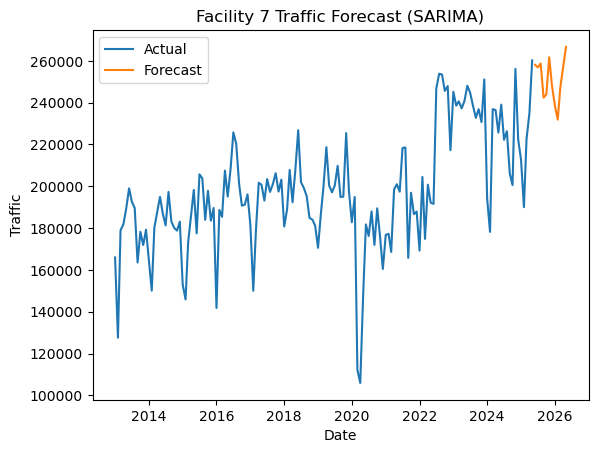

In [14]:
# -------------------------------
# 🔥 VISUALIZATION
# -------------------------------
plt.figure()

plt.plot(monthly, label="Actual")
plt.plot(forecast_values, label="Forecast")

plt.title("Facility 7 Traffic Forecast (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Traffic")
plt.legend()

plt.show()

### Forecast Interpretation

The visualization shows both historical and forecasted traffic.

Key observations:

- Traffic demand remains stable over time  
- Seasonal fluctuations continue to exist  
- No extreme upward or downward trend is observed  

This indicates that future traffic patterns will likely follow existing trends, with variation occurring at the facility level rather than system-wide changes.

## Overall Conclusion

The Python-based implementation successfully replicates the models identified through AutoML, demonstrating that the results are reproducible and interpretable.

The regression model provides accurate predictions of traffic volume, the classification model effectively identifies high traffic conditions, and the time-series model delivers realistic forecasts of future demand.

Together, these models provide a comprehensive understanding of traffic behavior and support data-driven decision-making for planning, congestion management, and operational optimization.

---